# Simulations of compartmental model

There are interesting conceptual questions about simulating the models we've been discussing so far. How can we run a model in continuous time using the discrete data structures and logic of programming? The big conceptual jump one needs to make to do exact direct simulations of a continuous time process is to think of time in terms of number of events rather than temporal units. By discretely jumping from one event to the next, one can exactly follow the process in continuous time!

And for compartmental or mean-field models, this task is actually pretty easy! We do not need to track every possible agent of the system and check what they might do next. All agents in a given compartments are identical or indistinguishable. They all have the same possible transitions and all change states at the same rate. In this context, we therefore suggest using what is called a Next Reaction Method.

## Next Reaction Method

For Markovian models, it is much faster to focus on the time to the *next* event in the series to limit the number of random numbers drawn. One can then, 
* Evaluate all the rates $r_i(x,t)$ of all possible events $i$ as well as their sum $R = \sum_i r_i(x,t)$.
* Draw time $\tau$ to the next event from a total process occurring at rate $R$.
* Pick the exact event $i$ proportionally $r_i(x,t)$, record that event and repeat.

Reference: 
- Gibson and Bruck (2000), **_Efficient Exact Stochastic Simulation of Chemical Systems with Many Species and Many Channels_** {cite}`gibson2000efficient`

Bla bla introduce a cell division example...

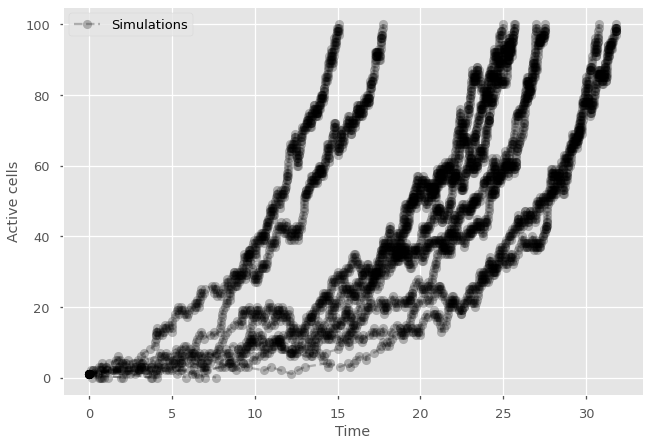

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
plt.style.use(['ggplot', 'seaborn-talk'])

#parameters
P_division = 1/2
P_death = 1/3

#for each simulation
for sims in range(25):
    
    #initial conditions
    active_cells = 1
    time = 0
    history = np.ones(1)
    times = np.zeros(1)
    
    #for each generation
    while active_cells < 100 and active_cells > 0:
        
        #calculate total rate R
        R_div = P_division*active_cells
        R_death = P_death*active_cells
        R = R_div + R_death
        
        #draw time to next event and event type
        tau = np.random.exponential(scale=1/R)
        if random.random() < R_div/R:
            active_cells+=1
        else:
            active_cells-=1
            
        #update history
        time = time+tau
        history = np.append(history, active_cells)
        times = np.append(times, time)
        
    #print time series
    plt.plot(times,history, marker="o", ls='--', color='black', alpha=0.25)
    
#Add null simulation with label in legend and label the axes
plt.plot(0,1, marker="o", ls='--', color='black', alpha=0.25, label='Simulations')
plt.legend()
plt.ylabel('Active cells')
plt.xlabel('Time')
plt.show()

## Comparison with mathematical model

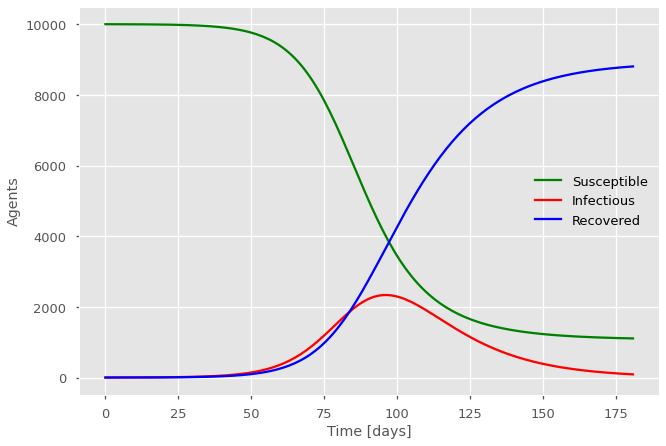

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use(['ggplot', 'seaborn-talk'])

# We will use the odeint routine
from scipy.integrate import odeint

# Master Equations
def J(x, t, beta, alpha):
    """
    Time derivative of the occupation numbers.

        * x is the state distribution (array like)
        * t is time (scalar)
        * beta is the transmission rate
        * alpha is the recovery rate
    """
    
    dx = 0*x #setting the data structure for every variable
    dx[0] = -beta*x[0]*x[1] #derivative for S
    dx[1] = beta*x[0]*x[1] - alpha*x[1] #derivative for I
    dx[2] = alpha*x[1] #derivative for R

    return dx

# Parameters
N = 10000 #population
beta = 1/6*1/N #transmission time per contact: 6 days. contacts per day: N
alpha = 1/15 #recovery period: 15 days

# Time of observations
t_length = 182
t_vec = np.arange(0, t_length)

# Initial conditions
x_0 = np.zeros(3)
x_0[0] = N-1; x_0[1] = 1; x_0[2] = 0

# Integration
G = lambda x, t: J(x, t, beta, alpha)
x_path = odeint(G, x_0, t_vec)

# Plot
fig,ax = plt.subplots()
ax.plot(t_vec, x_path[:,0], 'g', label='Susceptible')
ax.plot(t_vec,x_path[:,1], 'r', label='Infectious')
ax.plot(t_vec,x_path[:,2], 'b', label='Recovered')
plt.xlabel('Time [days]')
plt.ylabel('Agents')
ax.legend(frameon=False);